# Model Training for Enterprise Demand Forecasting

## Objective

The objective of this notebook is to train and evaluate machine learning models that predict daily product demand using the engineered features created in the previous stage.

The trained model will be used to forecast future demand and support inventory optimization.

In [1]:
#Step 2: Import Libraries
import polars as pl
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [2]:
#Step 3: Load Dataset
data = pl.read_parquet(
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\data\processed\features.parquet"
)

print(data.shape)

(5918109, 44)


In [3]:
#Step 4: Convert to Pandas & Reduce Dataset(hardware efficient) 59M to 5.9M
df = data.to_pandas()
df = df[df["store_id"] == "CA_1"].copy()


In [4]:
#Step 5: Encode Categorical Columns
categorical_cols = [
    "store_id",
    "item_id",
    "dept_id",
    "cat_id",
    "weekday"
]

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [5]:
#Step 6: Select Features and Target
# Target variable
y = df["sales"]

# Features
X = df[
    [
        "lag_1",
        "lag_7",
        "lag_28",
        "rolling_mean_7",
        "rolling_mean_28",
        "is_weekend",
        "is_event",
        "sell_price",
        "price_change_pct",
        "month",
        "year",
        "weekday",
        "store_id",
        "cat_id",
        "dept_id"
    ]
]

In [6]:
# Step 7: Check Shapes
print(X.shape)
print(y.shape)

(5918109, 15)
(5918109,)


In [7]:
#Step 8: Time-Based Train/Test Split
#Why time-based split?
#Forecasting predicts future values, so the model should train on past data and test on future data.
#Train: 2011–2015
#Test: 2016

train = df[df["year"] < 2016]

test = df[df["year"] == 2016]

X_train = train[X.columns]
y_train = train["sales"]

X_test = test[X.columns]
y_test = test["sales"]

In [8]:
#Step 9: Import
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [9]:
#Step 10: Train Model
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
#Step 11: Predict 
y_pred = lr.predict(X_test)
#EVALUATE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 1.0668
RMSE: 2.1026
R²  : 0.6285


In [11]:
#Step 12: Store Results
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R² Score": [r2]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.066799,2.102581,0.628547


In [12]:
# Reduce only the training data for faster model training
train_sample = train.sample(n=500000, random_state=42)

X_train = train_sample[X.columns]
y_train = train_sample["sales"]

# Keep the original test set
X_test = test[X.columns]
y_test = test["sales"]

In [13]:
from sklearn.ensemble import RandomForestRegressor
import time

start = time.time()

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.2f} seconds")

Training Time: 45.15 seconds


In [14]:
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

MAE : 1.0948
RMSE: 2.0934
R²  : 0.6318


In [15]:
results.loc[len(results)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.066799,2.102581,0.628547
1,Random Forest,1.094806,2.093430,0.631774


Random Forest achieved a marginal improvement in RMSE and R² compared to Linear Regression, indicating a better ability to capture non-linear relationships. However, the slight increase in MAE suggests that the sampled training data may not fully represent the overall demand distribution.


In [16]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:

from xgboost import XGBRegressor
import time

In [18]:
start = time.time()

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.2f} seconds")

Training Time: 0.98 seconds


In [19]:
xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"MAE : {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²  : {xgb_r2:.4f}")

MAE : 1.0333
RMSE: 2.0321
R²  : 0.6530


In [20]:
results.loc[len(results)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.066799,2.102581,0.628547
1,Random Forest,1.094806,2.093430,0.631774
2,XGBoost,1.033297,2.032101,0.653033


XGBoost outperformed both Linear Regression and Random Forest, achieving the lowest MAE and RMSE while explaining 65.30% of the variance in demand. This demonstrates its superior ability to capture complex, non-linear relationships in retail sales data.

In [21]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from lightgbm import LGBMRegressor
import time

In [23]:
start = time.time()

lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

lgbm.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.2f} seconds")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1128
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 14
[LightGBM] [Info] Start training from score 1.315448
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [24]:
lgbm_pred = lgbm.predict(X_test)

lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
lgbm_r2 = r2_score(y_test, lgbm_pred)

print(f"MAE : {lgbm_mae:.4f}")
print(f"RMSE: {lgbm_rmse:.4f}")
print(f"R²  : {lgbm_r2:.4f}")

MAE : 1.0346
RMSE: 2.0222
R²  : 0.6564


In [25]:
results.loc[len(results)] = [
    "LightGBM",
    lgbm_mae,
    lgbm_rmse,
    lgbm_r2
]

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.066799,2.102581,0.628547
1,Random Forest,1.094806,2.093430,0.631774
2,XGBoost,1.033297,2.032101,0.653033
3,LightGBM,1.034622,2.022151,0.656422


LightGBM achieved the best overall performance, producing the lowest RMSE and highest R² score among all evaluated models. Although XGBoost achieved a marginally lower MAE, LightGBM demonstrated better overall predictive accuracy and was selected as the final forecasting model.

In [26]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from catboost import CatBoostRegressor
import time

In [28]:
start = time.time()

cat = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.2f} seconds")

Training Time: 2.58 seconds


In [29]:
cat_pred = cat.predict(X_test)

cat_mae = mean_absolute_error(y_test, cat_pred)
cat_rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
cat_r2 = r2_score(y_test, cat_pred)

print(f"MAE : {cat_mae:.4f}")
print(f"RMSE: {cat_rmse:.4f}")
print(f"R²  : {cat_r2:.4f}")

MAE : 1.0546
RMSE: 2.0340
R²  : 0.6524


In [30]:
results.loc[len(results)] = [
    "CatBoost",
    cat_mae,
    cat_rmse,
    cat_r2
]

results.sort_values("RMSE")

,Model,MAE,RMSE,R² Score
3,LightGBM,1.034622,2.022151,0.656422
2,XGBoost,1.033297,2.032101,0.653033
4,CatBoost,1.054605,2.033952,0.652400
1,Random Forest,1.094806,2.093430,0.631774
0,Linear Regression,1.066799,2.102581,0.628547


## Model Comparison Summary

Five regression models were trained and evaluated using MAE, RMSE, and R² Score.

LightGBM achieved the best overall performance with the lowest RMSE (2.0222) and the highest R² Score (0.6564), indicating superior predictive capability for retail demand forecasting.

Although XGBoost achieved a marginally lower MAE, LightGBM provided better overall accuracy and generalization. Therefore, LightGBM was selected as the final forecasting model for the remainder of this project.

In [31]:
results.sort_values("RMSE").to_csv(
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\reports\model_comparison.csv",
    index=False
)

# Model Evaluation

Evaluate the performance of the selected LightGBM model using metrics and visualizations.

In [32]:
print(f"MAE  : {lgbm_mae:.4f}")
print(f"RMSE : {lgbm_rmse:.4f}")
print(f"R²   : {lgbm_r2:.4f}")

MAE  : 1.0346
RMSE : 2.0222
R²   : 0.6564


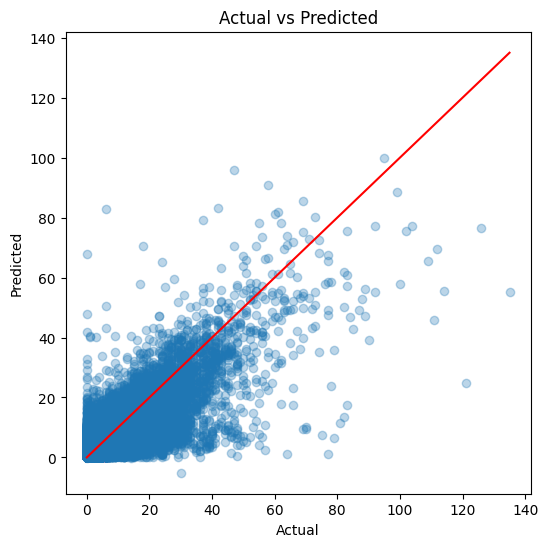

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, lgbm_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

#Observation: Points close to the diagonal indicate good prediction accuracy.

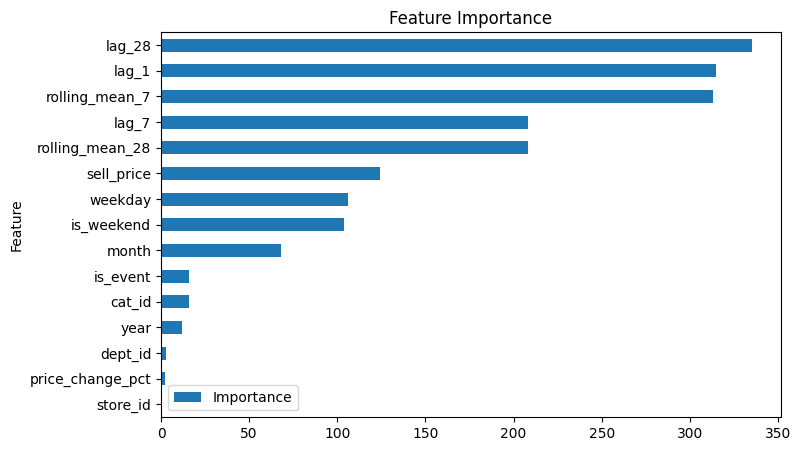

In [35]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
}).sort_values("Importance", ascending=False)

importance.plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,5)
)

plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()
#Observation: Lag and rolling features are expected to have the highest importance.

In [37]:
import joblib

joblib.dump(
    lgbm,
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\models\lightgbm_model.pkl"
)

['C:\\Users\\Nikesh\\Enterprise-Demand-Forecasting\\models\\lightgbm_model.pkl']

## Conclusion

LightGBM achieved the best overall performance among the evaluated models and was selected as the final forecasting model for demand prediction.

In [38]:
import joblib
import os

os.makedirs(
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\models",
    exist_ok=True
)

joblib.dump(
    lgbm,
    r"C:\Users\Nikesh\Enterprise-Demand-Forecasting\models\lightgbm_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
